## Tarea 1: Repaso básicos de ML — material de práctica (no calificado)

Esta tarea **ya no se entrega ni se califica**. Es material de práctica y preparación: los exámenes evalúan la teoría detrás de estos experimentos (temarios en `Examenes/`) y el proyecto de colaboración con IA usa este mismo protocolo experimental.

Sugerencias para sacarle provecho:
1. Puedes usar LLMs o agentes de IA libremente — de hecho es buen entrenamiento para el proyecto final. Pero recuerda: los exámenes son en clase y a mano, evalúan que *tú* entiendas.
2. Antes de correr cada experimento, escribe qué esperas observar y por qué; después compara con lo que obtuviste.
3. Asegúrate de entender cada línea del código (tuyo o del agente); consulta la documentación de PyTorch.
4. Mantén el protocolo experimental del curso: semilla fija, mismos splits, un factor variado a la vez, curvas + tabla resumen + interpretación.

Las siguientes preguntas son de implementación utilizando el notebook que tenemos de Intro_Pytorch. 

1. Regresión lineal desde cero: 

    a. Define un modelo lineal utilizando `nn.Linear(1,1)` y entrena utilizando la función `synthetic_regression_data` del notebook

    b. Con los mismo datos, define un modelo utilizando la `LinearRegression` que nosotros generamos

    c. Compara los resultados que generan estas dos. ¿Cuál es la diferencia? 

2. Batch vs. Minibatch:
    
    a. Entrena con `batch_size = n` (el ejemplo del notebook) con batch_size = 16, 32  y 64

    b. Grafica la pérdida por época en los tres casos y comenta las diferencias en estabilidad y velocidad de convergencia.

3. Closed-form vs. GD:
    
    a. Usa `torch.linalg.lstsq` o la fórmula cerrada para obtener w y b

    b. Compara sus valores con los aprendidos por GD tras converger (misma escala y ruido).

4. Decay de la learning rate:

    a. Usa `torch.optim.lr_scheduler.StepLR` con step = 100 epochs, γ = 0.1.
    b. Registra la lr en cada época y muéstrala junto a la pérdida para ver el efecto del decaimiento.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [3]:
# 1) Creamos datos sinteticos para probar nuestra infra: 
def synthetic_regression_data(w, b, num_samples=1000):
    """Genera X ~ N(0,1) y y = Xw + b + ruido."""
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1, 1) + b
    y += torch.randn_like(y) * 0.01  # agrega ruido a nuestros datos 
    return X, y


In [4]:
# 2) Preparamos datos y dataloaders
true_w = torch.tensor([2.0])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)


# 3) Crear TensorDataset y dividir en train/validation
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 4) Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [5]:
model_1 = nn.Linear(1,1)
optim = torch.optim.SGD(model_1.parameters(), lr=0.03)

In [6]:
# 6) Entrenamiento: 
num_epochs = 10
# Listas para almacenar la pérdida media de cada epoch
train_losses, val_losses = [], []
loss_fn = nn.MSELoss()
for epoch in range(1, num_epochs + 1):
    # activa el modo entrenamiento (acá no lo necesitamos porque lo estamos haciendo a mano, pero es buena práctica)
    model_1.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model_1(Xb)      
        loss = loss_fn(y_hat, yb)/2
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_train += loss.item() * yb.shape[0] 
        count_train += yb.shape[0]
    train_losses.append(total_train / count_train) # guardamos la pérdida media por ejemplo 

    # Fase de validación
    model_1.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = loss_fn(model_1(Xv), yv)/2
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
    val_losses.append(total_val / count_val)

# 7) Evaluación final de los parámetros aprendidos
with torch.no_grad():
    est_w = model_1.weight.reshape(true_w.shape)
    est_b = model_1.bias
    print("Error en w:", true_w - est_w)
    print("Error en b:", true_b - est_b)


Error en w: tensor([0.0023])
Error en b: tensor([0.0025])


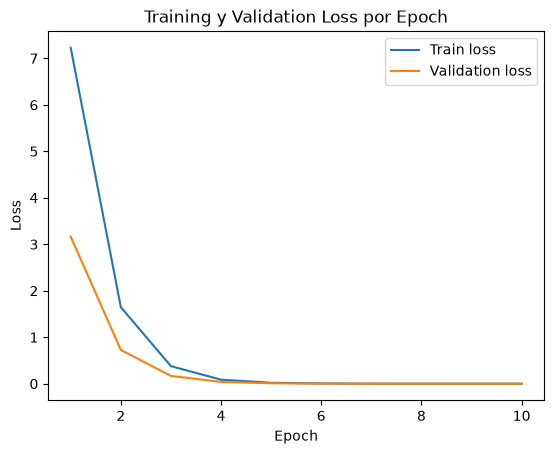

In [7]:
# 8) Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()

# Con las celdas originales

In [8]:
# paquete central de PyTorch; contiene tensores y las operaciones sobre ellos.
import torch
# módulos y capas de red (e.g., Linear, ReLU, CrossEntropyLoss).
import torch.nn as nn

class LinearRegression(nn.Module):
    """Modelo de regresión lineal implementado desde cero en PyTorch"""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super(LinearRegression, self).__init__()
        # Guardamos los hiperparámetros “a mano”, lo que le pasamos se asigna a la instancia en particular
        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma
        # Parámetros del modelo: pesos y sesgo
        # nn.Parameter indica a PyTorch que debe calcular gradientes sobre este tensor
        self.w = nn.Parameter(
            torch.normal(0.0, sigma, size=(num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )
    
    def forward(self, X):
        """ Calcula la estimación y_hat dados los paramétros actuales y X"""
        return torch.matmul(X, self.w) + self.b
    
    def loss(self, y_hat, y):
        """Calcula la pérdida de regresión lineal
        y devuelve el valor medio sobre el minibatch.
        """
        # 1) Error al cuadrado, escalado por 1/2
        l = (y_hat - y) ** 2 / 2
        # 2) Promedio sobre todas las muestras
        return l.mean()
    
    def configure_optimizers(self):
        """
        Crea y devuelve el optimizador SGD configurado con nuestros parámetros.
        """
        # Pasamos los parámetros w y b al optimizador y la lr
        return SGD([self.w, self.b], self.lr)

In [9]:
class SGD:
    """Descenso de gradiente estocástico por minibatches."""
    def __init__(self, params, lr):
        # params: iterable de nn.Parameter
        self.params = list(params)
        self.lr = lr

    def step(self):
        """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
        for p in self.params:
            # p.grad es el gradiente calculado en backward()
            p.data -= self.lr * p.grad

    def zero_grad(self):
        """Pone a cero todos los gradientes para la siguiente iteración."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


Error en w: tensor([0.0022])
Error en b: tensor([0.0023])


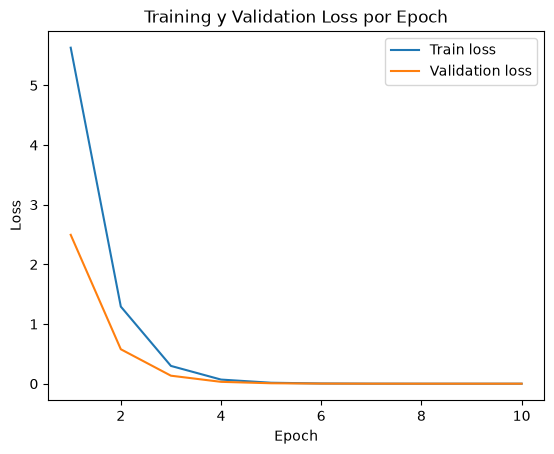

In [10]:
# 5) Instanciamos el modelo y el optimizador
model = LinearRegression(num_inputs = 1, lr = 0.03)
optim = model.configure_optimizers()  # nuestra clase SGD

# 6) Entrenamiento: 
num_epochs = 10
# Listas para almacenar la pérdida media de cada epoch
train_losses, val_losses = [], []
for epoch in range(1, num_epochs + 1):
    # activa el modo entrenamiento (acá no lo necesitamos porque lo estamos haciendo a mano, pero es buena práctica)
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad() # pone en cero los gradientes acumulados de parámetros
        loss.backward() # calcula gradientes de la pérdida respecto a cada parámetro del modelo
        optim.step() # actualiza los parámetros usando esos gradientes
        total_train += loss.item() * yb.shape[0] # convierte la pérdida del tensor a número .item() 
        # se multiplica por yb.shape[0] para deshacer el promedio del batch y 
        # acumular la suma de pérdidas. Esto nos da la pérdida media ponderada 
        # por si los últimos batches no son del mismo tamaño 
        count_train += yb.shape[0]
        # número total de ejemplos vistos en la época  
    train_losses.append(total_train / count_train) # guardamos la pérdida media por ejemplo 

    # Fase de validación
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]
    val_losses.append(total_val / count_val)

# 7) Evaluación final de los parámetros aprendidos
with torch.no_grad():
    est_w = model.w.reshape(true_w.shape)
    est_b = model.b
    print("Error en w:", true_w - est_w)
    print("Error en b:", true_b - est_b)

# 8) Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()


# Mini batches

Error en w: tensor([-3.9816e-05])
Error en b: tensor([0.0006])


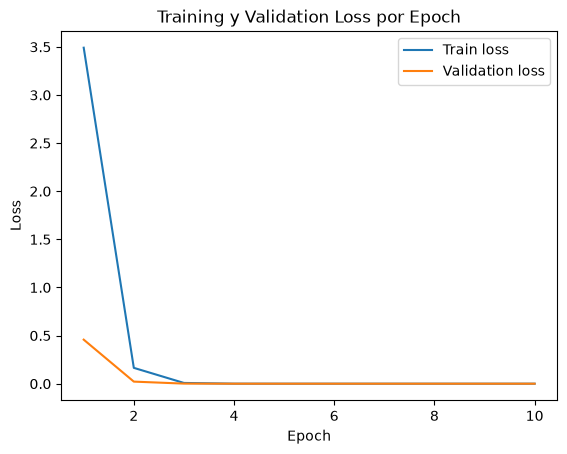

Error en w: tensor([0.0009])
Error en b: tensor([0.0026])


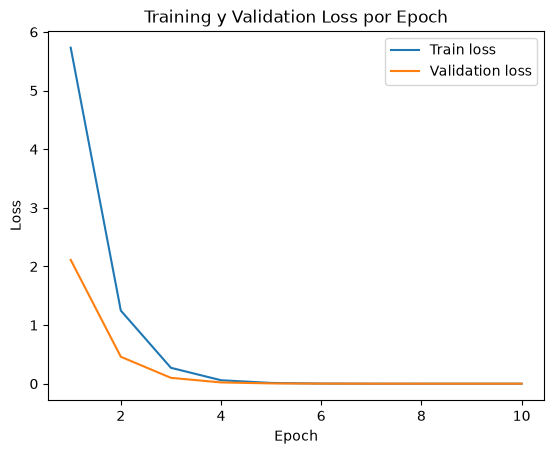

Error en w: tensor([0.0386])
Error en b: tensor([0.0803])


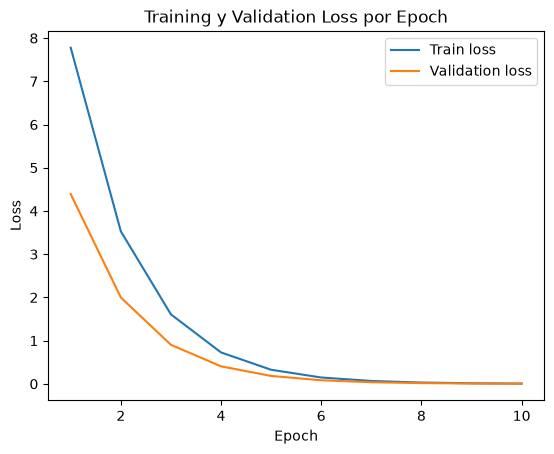

In [14]:
# 2) Preparamos datos y dataloaders
true_w = torch.tensor([2.0])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)


# 3) Crear TensorDataset y dividir en train/validation
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 4) Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


# 4) Crear DataLoaders
batch_list = [16, 32, 64]
for n in batch_list:
    batch_size = n
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = LinearRegression(num_inputs = 1, lr = 0.03)
    optim = model.configure_optimizers()  # nuestra clase SGD

    # 6) Entrenamiento: 
    num_epochs = 10
    # Listas para almacenar la pérdida media de cada epoch
    train_losses, val_losses = [], []
    for epoch in range(1, num_epochs + 1):
        # activa el modo entrenamiento (acá no lo necesitamos porque lo estamos haciendo a mano, pero es buena práctica)
        model.train()
        total_train, count_train = 0.0, 0
        for Xb, yb in train_loader:
            y_hat = model(Xb)
            loss = model.loss(y_hat, yb)
            optim.zero_grad() # pone en cero los gradientes acumulados de parámetros
            loss.backward() # calcula gradientes de la pérdida respecto a cada parámetro del modelo
            optim.step() # actualiza los parámetros usando esos gradientes
            total_train += loss.item() * yb.shape[0] # convierte la pérdida del tensor a número .item() 
            # se multiplica por yb.shape[0] para deshacer el promedio del batch y 
            # acumular la suma de pérdidas. Esto nos da la pérdida media ponderada 
            # por si los últimos batches no son del mismo tamaño 
            count_train += yb.shape[0]
            # número total de ejemplos vistos en la época  
        train_losses.append(total_train / count_train) # guardamos la pérdida media por ejemplo 

        # Fase de validación
        model.eval()
        total_val, count_val = 0.0, 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                loss_val = model.loss(model(Xv), yv)
                total_val += loss_val.item() * yv.shape[0]
                count_val += yv.shape[0]
        val_losses.append(total_val / count_val)

    # 7) Evaluación final de los parámetros aprendidos
    with torch.no_grad():
        est_w = model.w.reshape(true_w.shape)
        est_b = model.b
        print("Error en w:", true_w - est_w)
        print("Error en b:", true_b - est_b)

    # 8) Graficar pérdidas
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training y Validation Loss por Epoch')
    plt.show()

* Velocidad por época: con batches pequeños se dan muchos más pasos por época, así que la pérdida baja en menos épocas. Con batch_size = n solo hay 1 paso por época: en 10 épocas apenas avanzará. Recuerda que en la réplica necesitaste ~300 pasos con todos los datos.
* Estabilidad: con batches pequeños cada gradiente se estima con pocos ejemplos, así que es más ruidoso. Con estos datos, casi sin ruido, puede que no se note mucho en la curva por época. Si quieres verlo, registra la pérdida por batch en lugar de por época.

# GD vs SGD

In [15]:
help (torch.linalg.lstsq)

Help on built-in function linalg_lstsq in module torch._C._linalg:

linalg_lstsq(...)
    torch.linalg.lstsq(A, B, rcond=None, *, driver=None) -> (Tensor, Tensor, Tensor, Tensor)

    Computes a solution to the least squares problem of a system of linear equations.

    Letting :math:`\mathbb{K}` be :math:`\mathbb{R}` or :math:`\mathbb{C}`,
    the **least squares problem** for a linear system :math:`AX = B` with
    :math:`A \in \mathbb{K}^{m \times n}, B \in \mathbb{K}^{m \times k}` is defined as

    .. math::

        \min_{X \in \mathbb{K}^{n \times k}} \|AX - B\|_F

    where :math:`\|-\|_F` denotes the Frobenius norm.

    Supports inputs of float, double, cfloat and cdouble dtypes.
    Also supports batches of matrices, and if the inputs are batches of matrices then
    the output has the same batch dimensions.

    :attr:`driver` chooses the backend function that will be used.
    For CPU inputs the valid values are `'gels'`, `'gelsy'`, `'gelsd`, `'gelss'`.
    To choose the b

In [32]:
a = torch.ones(X.shape[0], 1)

In [34]:
a.shape

torch.Size([1000, 1])

In [36]:
A = torch.cat((X,a), dim=1)
B = y

tensor([[ 1.5271e-01],
        [-8.1238e-01],
        [ 1.9961e-01],
        [-9.8320e-01],
        [-8.3759e-01],
        [ 8.4630e-01],
        [ 7.9570e-01],
        [-7.2712e-01],
        [ 2.6196e-01],
        [ 1.4002e+00],
        [-7.9694e-01],
        [ 1.3654e+00],
        [ 9.0133e-01],
        [-1.6554e-01],
        [-4.6152e-01],
        [-1.5737e+00],
        [ 5.0596e-01],
        [ 2.4263e-01],
        [-1.0439e+00],
        [-5.6968e-01],
        [-3.0891e+00],
        [-2.9569e-01],
        [-1.7110e+00],
        [ 1.7986e+00],
        [-4.1504e-01],
        [-9.4005e-02],
        [-2.6949e+00],
        [-2.1175e+00],
        [-4.5745e-01],
        [-3.6949e-01],
        [ 4.1171e-01],
        [ 1.1609e+00],
        [-2.0894e-01],
        [ 1.0869e+00],
        [ 1.2524e+00],
        [ 2.6346e-01],
        [ 1.1828e+00],
        [ 1.6861e+00],
        [-1.9306e-02],
        [-1.1777e+00],
        [ 9.5581e-01],
        [-3.0336e-01],
        [ 4.7429e-01],
        [ 1

In [37]:
torch.linalg.lstsq(A, B)

torch.return_types.linalg_lstsq(
solution=tensor([[2.0001],
        [4.1994]]),
residuals=tensor([]),
rank=tensor(2),
singular_values=tensor([]))

In [38]:
print(est_w)

tensor([1.9614], requires_grad=True)


In [39]:
print(est_b)

Parameter containing:
tensor([4.1197], requires_grad=True)
